In [1]:
import setup
from src.utils.my_plotting import new_fig, finish_fig, plot_corr_mat

In [ ]:
import polars as pl
from polars import col as c
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
INPUT = '../data/processed/features.parquet'

In [ ]:
lf = pl.scan_parquet(INPUT).sort(['ticker', 'date'])

In [8]:
lf.describe()

statistic,ticker,date,open,high,low,close,volume,logret,mom5,mom10,mom20,mom60,mom120,mom252,std5,std10,std20,std60,std120,std252,dollar_volume,adv5,adv10,adv20,adv60,adv120,adv252
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""2917517""","""2917517""",2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917016e6,2.915012e6,2.912507e6,2.907501e6,2.887532e6,2.857592e6,2.791802e6,2.915513e6,2.913008e6,2.908001e6,2.888031e6,2.858091e6,2.7923e6,2.917517e6,2.915513e6,2.913008e6,2.908001e6,2.888031e6,2.858091e6,2.7923e6
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,501.0,2505.0,5010.0,10016.0,29985.0,59925.0,125715.0,2004.0,4509.0,9516.0,29486.0,59426.0,125217.0,0.0,2004.0,4509.0,9516.0,29486.0,59426.0,125217.0
"""mean""",null,"""2014-01-27 09:58:18.835345""",85.111451,86.11896,84.082275,74.978281,8.5368e6,0.000447,0.003546,0.006957,0.013849,0.041089,0.083094,0.182129,1.175455,1.628695,2.266514,3.883421,5.426856,7.762801,2.7487e8,2.7471e8,2.7435e8,2.7355e8,2.7098e8,2.6800e8,2.6223e8
"""std""",null,null,198.358845,200.748997,195.980598,195.59945,4.7475e7,0.023507,0.051028,0.070492,0.09925,0.172815,0.264241,0.535469,3.70646,4.880477,6.53049,10.836028,15.091282,21.100498,1.1689e9,1.1253e9,1.1085e9,1.0905e9,1.0551e9,1.0304e9,9.8818e8
"""min""","""A""","""2000-01-03""",0.030208,0.030521,0.026979,0.030521,0.0,-1.141076,-0.882857,-0.909212,-0.898093,-0.95309,-0.981547,-0.992031,0.0,0.0,0.0,1.0085e-7,0.001131,0.001603,0.0,0.0,0.0,0.0,0.0,117.003742,132.10673
"""25%""",null,"""2007-09-25""",23.629999,23.95652,23.299999,16.2519,953400.0,-0.009076,-0.019325,-0.02592,-0.034617,-0.046919,-0.049069,-0.040222,0.190806,0.281103,0.404545,0.72237,1.035151,1.546684,3.4015e7,3.6421e7,3.7357e7,3.8183e7,3.9296e7,3.9932e7,4.1101e7
"""50%""",null,"""2014-06-23""",45.66,46.189999,45.119999,34.29525,2.23771e6,0.000575,0.003466,0.006833,0.013358,0.037168,0.069297,0.137391,0.435232,0.621189,0.881077,1.544671,2.208176,3.269517,9.4971e7,9.9410e7,1.0113e8,1.0254e8,1.0402e8,1.0436e8,1.0509e8
"""75%""",null,"""2020-08-19""",89.559998,90.540001,88.548111,77.082573,5.4445e6,0.010237,0.025927,0.039094,0.060076,0.120424,0.18923,0.327428,1.047196,1.474121,2.072065,3.600711,5.088395,7.36996,2.2663e8,2.3095e8,2.3222e8,2.3305e8,2.3336e8,2.3261e8,2.3051e8
"""max""","""ZTS""","""2026-07-08""",9914.169922,9964.769531,9794.0,9924.400391,9.2309e9,0.704868,3.715908,3.628573,3.588833,6.789738,14.338714,64.339399,542.224057,669.674785,682.70116,645.92675,873.528904,1060.954243,1.5438e11,8.0524e10,7.0171e10,6.1780e10,4.4935e10,4.3925e10,3.9001e10


## Random ticker -  visual inspection

In [5]:
df = lf.filter(
    c('ticker').is_in( c('ticker').unique().sample(1).implode() )
).collect().to_pandas().set_index('date')

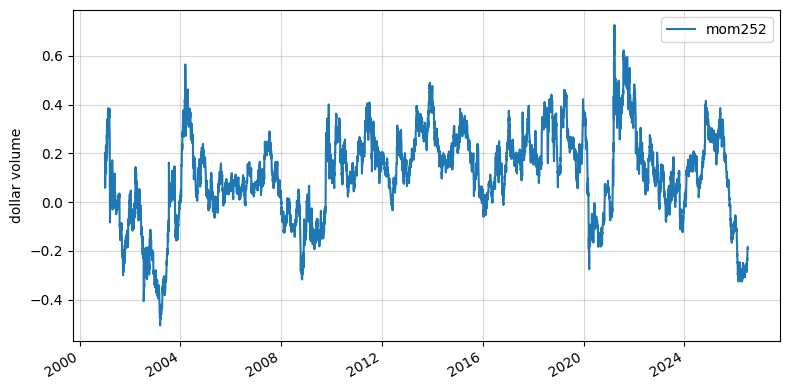

In [ ]:
f, ax = new_fig(fs=(8, 4))
df.plot( y='mom252', ax=ax)
# ax.grid()
finish_fig(ax, yl='mom-20 days')

## Null count

In [7]:
lf.null_count().collect()

ticker,date,open,high,low,close,volume,logret,mom5,mom10,mom20,mom60,mom120,mom252,std5,std10,std20,std60,std120,std252,dollar_volume,adv5,adv10,adv20,adv60,adv120,adv252
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,501,2505,5010,10016,29985,59925,125715,2004,4509,9516,29486,59426,125217,0,2004,4509,9516,29486,59426,125217


## Average number of observations per ticker

In [ ]:
lf.group_by('ticker').agg()

## Distributions

In [87]:
mom20 = ( 
    lf
    .select('mom20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
std20 = ( 
    lf
    .select('std20')
    .drop_nulls()
    .collect()
    .to_pandas()
)
adv20 = ( 
    lf
    .select('adv20')
    .drop_nulls()
    .collect()
    .to_pandas()
)

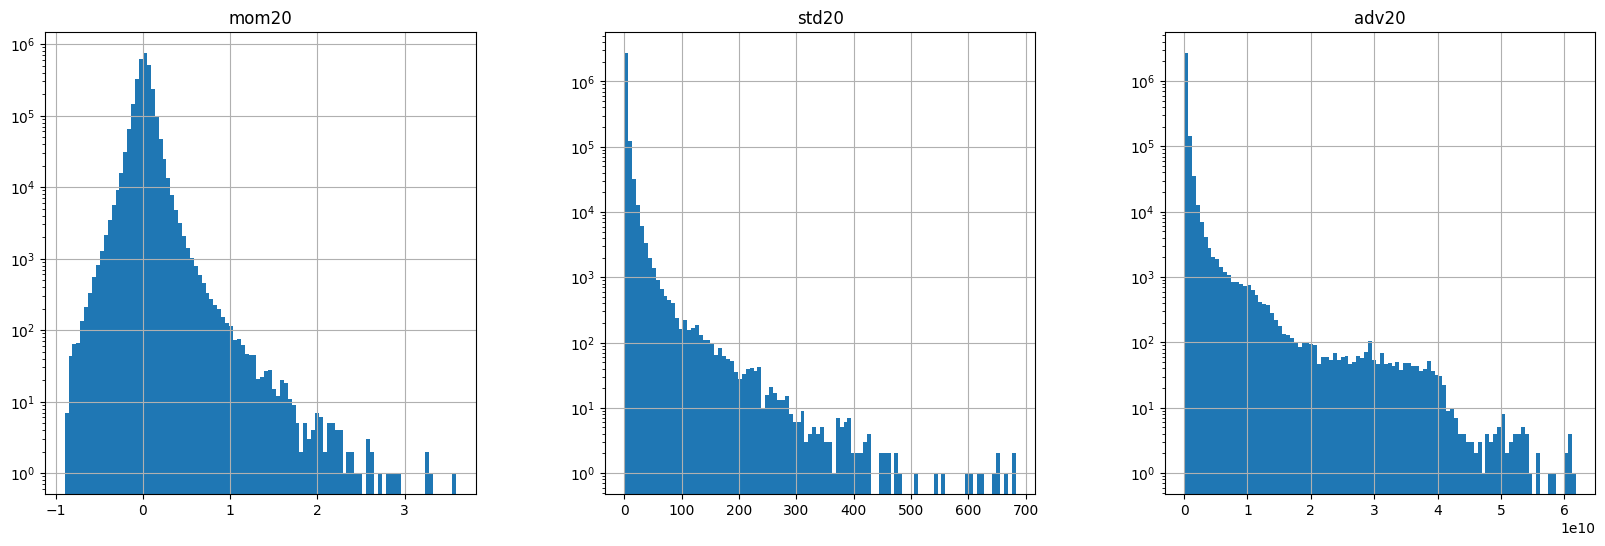

In [ ]:
f, ax = plt.subplots(1, 3, figsize=(20, 6))
mom20.hist(bins=100, ax=ax[0], log=True)
std20.hist(bins=100, ax=ax[1], log=True)
adv20.hist(bins=100, ax=ax[2], log=True);

In [8]:
feat = 'mom20'
(
    lf
    .select(
        c(feat).quantile(0.01).alias('Q1%'),
        c(feat).median().alias('median'),
        c(feat).quantile(0.99).alias('Q99%')
    )
    .collect()
)

Q1%,median,Q99%
f64,f64,f64
-0.252259,0.013358,0.293769


## Correlation

In [ ]:
Cmat = (
    lf
    .select(['mom5', 'mom20', 'mom120', 'mom252', 
             'std5', 'std20', 'std120', 'std252', 
             'adv5', 'adv20', 'adv120', 'adv252'])
    .drop_nulls()
    .collect()
    .to_pandas()
).corr()

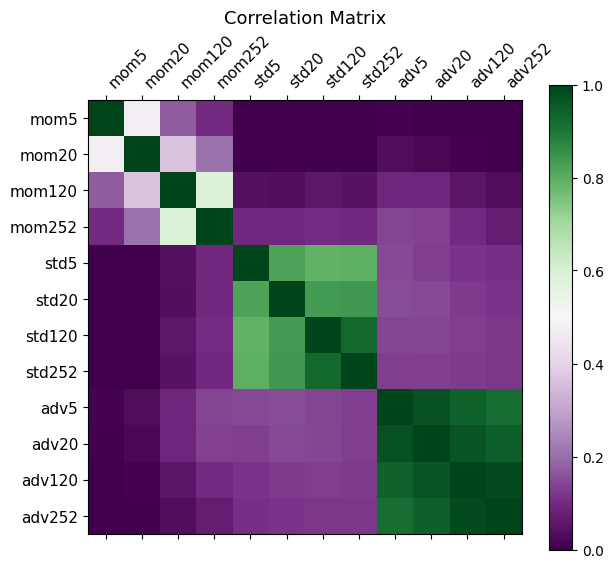

In [86]:
plot_corr_mat(Cmat, vmin=0)

## Stability over time

In [135]:
df_mom = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('mom20').mean().alias('mom_mean'),
        c('mom20').std().alias('mom_std'),
    )
).collect().to_pandas().set_index('date')
df_std = (
    lf
    .sort('date')
    .group_by_dynamic(
        'date',
        every='6mo'
    )
    .agg(
        c('std20').mean().alias('std_mean'),
        c('std20').std().alias('std_std'),
    )
).collect().to_pandas().set_index('date')

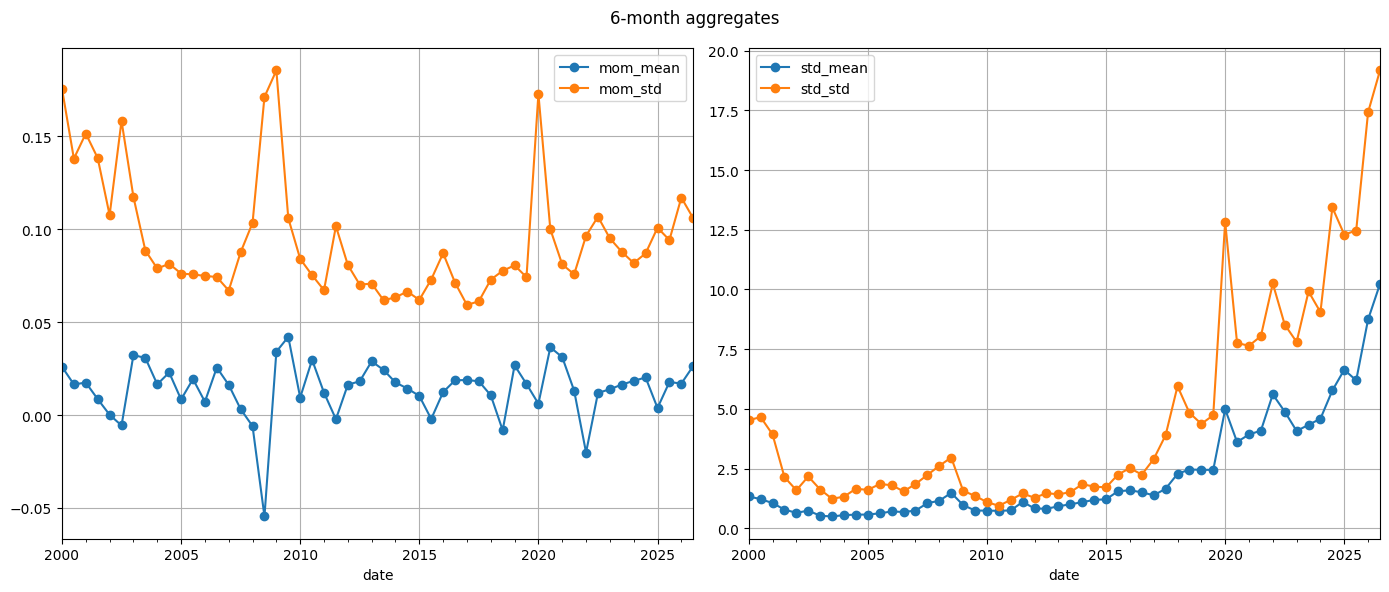

In [137]:
f, ax = plt.subplots(1, 2, figsize=(14, 6))
df_mom.plot(ax=ax[0], marker='o')
df_std.plot(ax=ax[1], marker='o')
ax[0].grid();ax[1].grid();f.suptitle('6-month aggregates');plt.tight_layout();

## QQ plots

In [138]:
df = (
    lf
    .select(['mom5', 'mom20', 'mom120', 'mom252', 
             'std5', 'std20', 'std120', 'std252', 
             'adv5', 'adv20', 'adv120', 'adv252'])
    .drop_nulls()
    .collect()
    .to_pandas()
)

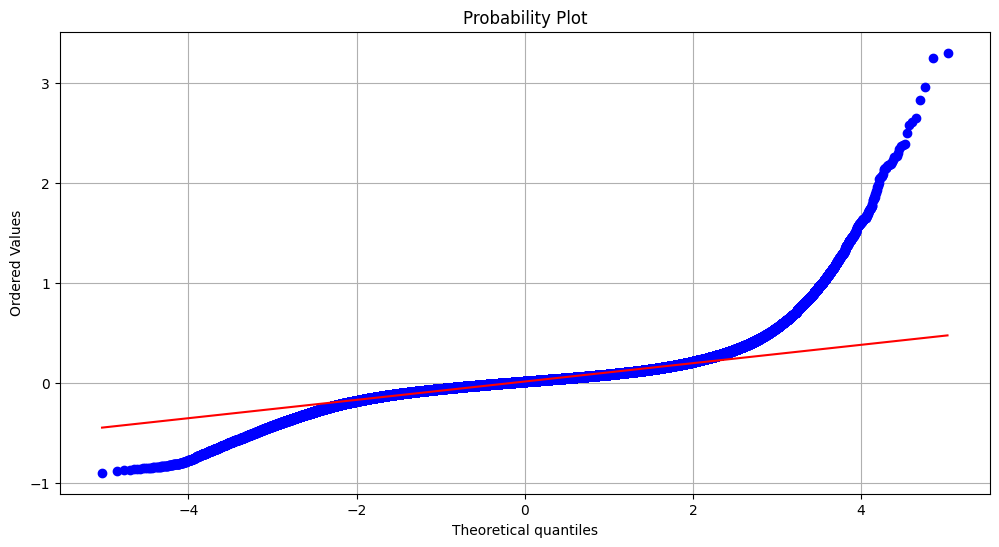

In [140]:
f, ax = new_fig()
stats.probplot(df['mom20'], plot=plt)
plt.grid()

## mom20 vs log-returns

In [ ]:
df = (
    lf
    .select(
        c('date'), 
        (
            c('logret')
            .shift(-1)
            .over('ticker')
            .alias('next_logret')
        ), 
        c('mom20')
    )
    .drop_nulls()
    .collect()
    .to_pandas()
    .set_index('date')
)

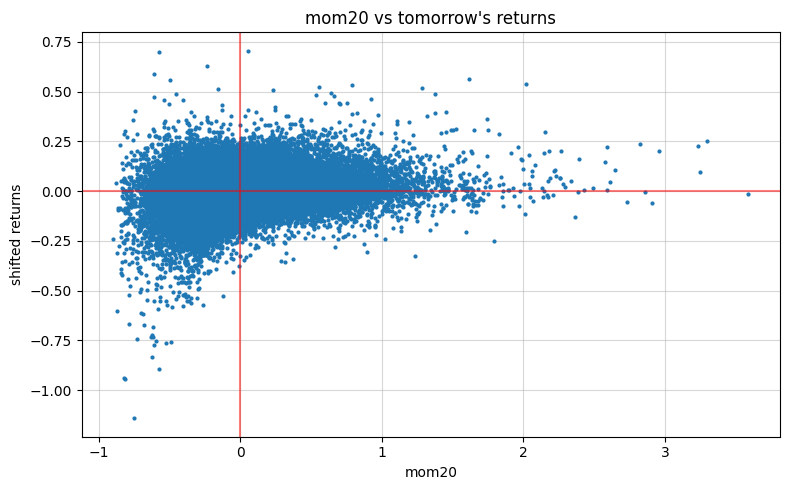

In [ ]:
f, ax = new_fig(fs=(8, 5))
plt.plot(df['mom20'], df['next_logret'], 'o', markersize=2)
plt.axhline(0, color='red', alpha=0.5);plt.axvline(0, color='red', alpha=0.5)
finish_fig(ax, xl='mom20', yl='shifted returns', title='mom20 vs tomorrow\'s returns')